In [22]:

# Importing functions for skew-T
import numpy as np
import matplotlib.pyplot as plt

#Import functios for accessing sounding data from the Wyoming Upper Air website

from datetime import datetime
from siphon.simplewebservice.wyoming import WyomingUpperAir


# Constants in SI units
Rd = 287.0       # J kg^-1 K^-1
Rv = 461.0       # J kg^-1 K^-1
cpd = 1004.0     # J kg^-1 K^-1
Lv = 2.5e6       # J kg^-1
g = 9.81         # m s^-2
Rd_cpd = Rd/cpd

# Pressure spacing in logarithmic format (.gromspace) going from 1000 to 100 hPa
p = np.geomspace(1000.0, 100.0, 1000)  # hPa


#Defining the skew-T function making temperature the horizontal axis and pressure the vertical axis
#Skew-T function skews temperature as the pressure continues logarithmically
def skewT(temp, pres, skew=-20):
    """
    Skews the temperature axis for a Skew-T plot.
    temp: temperature values (°C)
    pres: pressure values (hPa)
    skew: amount of skew (default -20)
    """
    return temp + skew * np.log(pres/1000.0)

In [23]:
#Calculating the dry-adiabats

#Defining the dry-adiabats by changing the temp to celsuis
def dry_adiabat(start_temp, pres, start_pres=1000.0):
    start_temp_k = start_temp+273.15
    temp_k = start_temp_k*(pres/start_pres)**Rd_cpd
    return temp_k-273.15

# Potential temperature should be constant along the curve, so potential temperature is calculated
dry_temp_k = dry_adiabat(30.0,p)+273.15
theta = dry_temp_k*(1000.0/p)**Rd_cpd


# Proof of concept for the dry adiabat and potential temperature calculations
# Proving that the minimum and maximum potential temperature fall along the curve
# Max/min theta are the same and have very little range from each other
# Potential temperature stays constant along dry-adiabat
print("Potential temperature range (K):", theta.min(), theta.max())
print("Largest difference from initial potential temp (theta):", theta.max()-theta.min())

Potential temperature range (K): 303.1499999999999 303.15000000000003
Largest difference from initial potential temp (theta): 1.1368683772161603e-13


In [24]:
#Defining moist adiabats and the variables that need to be included in the equation

#Defining saturation vapor pressure function using the Bolton approximation
#Units of saturation vapor pressure will be in hPa as K in the equation will cancel
def saturation_vapor_pressure(temp_k):
    return 6.112*np.exp(17.67*(temp_k-273.15)/(temp_k-29.65))


#Defining saturation mixing ratio, which will return units of kg/kg
#Use saturation vapor pressure for equation
def saturation_mixing_ratio(temp_k, pres):
    es = saturation_vapor_pressure(temp_k)
    return (Rd/Rv)*es/(pres-es)


#Defining moist lapse rate function, which will have units of K/m
#Separating numerator and denominator for ease of calculating
def moist_lapse_rate(temp_k, pres):
    rs = saturation_mixing_ratio(temp_k, pres)
    numerator = 1.0+Lv*rs/(Rd*temp_k)
    denominator = 1.0+Lv**2*rs/(cpd*Rv*temp_k**2)
    return (g/cpd)*numerator/denominator


#Defining moist adiabat functin, which will integrate a saturated parcel upward from the first pressure level
def moist_adiabat(start_temp, pres):
    temp_k = np.empty(len(pres))
    temp_k[0] = start_temp+273.15

    for i in range(1, len(pres)):
        p_previous = pres[i-1]
        p_current = pres[i]
        delta_ln_p = np.log(p_current/p_previous)

        # From hydrostatic balance and the moist lapse-rate equation, we can make a new equation and calculate
        # Start with moist lapse rate equation and saturated mixing ratio
        # Substitude ideal gas law into hydrostatic equation where you get dp/dz=-pg/R_d*T
        # Convert the temperature derivative from height to pressure coordinates using the chain rule of dT/dp=(dT/dz)/(dp/dz) substituting the equation from the hydrostatic equation and ideal gas law
        # Express the equation with logarithmic pressure where dlnp= dp/p or dT/dlnp=((R_d*T)/g)*the moist lapse rate
        dT_dlnp = (Rd*temp_k[i-1]/g*moist_lapse_rate(temp_k[i-1], p_previous))

        # Rearrange the equation to find the current temperature and then return the function in temperature in degrees C
        temp_k[i] = temp_k[i-1]+dT_dlnp*delta_ln_p

    return temp_k-273.15

In [25]:
# Proof of moist adiabats by comparing dry adiabatic lapse rate and moist adiabatic lapse rate
# As temperatures increase, but pressures remain the same, warmer saturated air contains more water vapor
# Shows that saturated parcels cool more slowly than unsaturated parcels, and this resembles the dry adiabatic versus the moist adiabatic lines on the skew-T; moist adiabatic lines are not as sloped at first compared to the dry adiabatic lines


dry_rate = 1000*g/cpd  # K/km

for start_temp in (-20.0, 0.0, 20.0):
    moist_rate = 1000*moist_lapse_rate(start_temp + 273.15, 1000.0)
    print(f"{start_temp:5.1f} °C: moist {moist_rate:.2f} K/km; "f"dry {dry_rate:.2f} K/km")

-20.0 °C: moist 8.61 K/km; dry 9.77 K/km
  0.0 °C: moist 6.48 K/km; dry 9.77 K/km
 20.0 °C: moist 4.22 K/km; dry 9.77 K/km


In [26]:
#Importing sounding data from the Wyoming Upper Air website for the Norman, OK (OUN) station on September 30, 2026 at 12Z

#Getting the specific souding data for September 30
sounding = WyomingUpperAir.request_data(datetime(2026, 9, 30, 12), "OUN")

# Getting pressure, temperature, and dewpoint data from the sounding and dropping any rows with missing values
sounding = sounding.dropna(subset=["pressure", "temperature", "dewpoint"])

sounding = sounding[sounding["pressure"].between(100, 1000)].sort_values("pressure")


# These lines convert the pressure, temperature, and dewpoint data from the sounding into numpy arrays for plotting
sound_p = sounding["pressure"].to_numpy()
sound_t = sounding["temperature"].to_numpy()
sound_td = sounding["dewpoint"].to_numpy()

print(sounding[["pressure", "temperature", "dewpoint"]].head())

     pressure  temperature  dewpoint
116     100.0        -73.7     -85.7
115     102.0        -75.3     -86.3
114     106.0        -74.1     -86.1
113     107.0        -74.5     -85.5
112     121.5        -68.6     -84.3


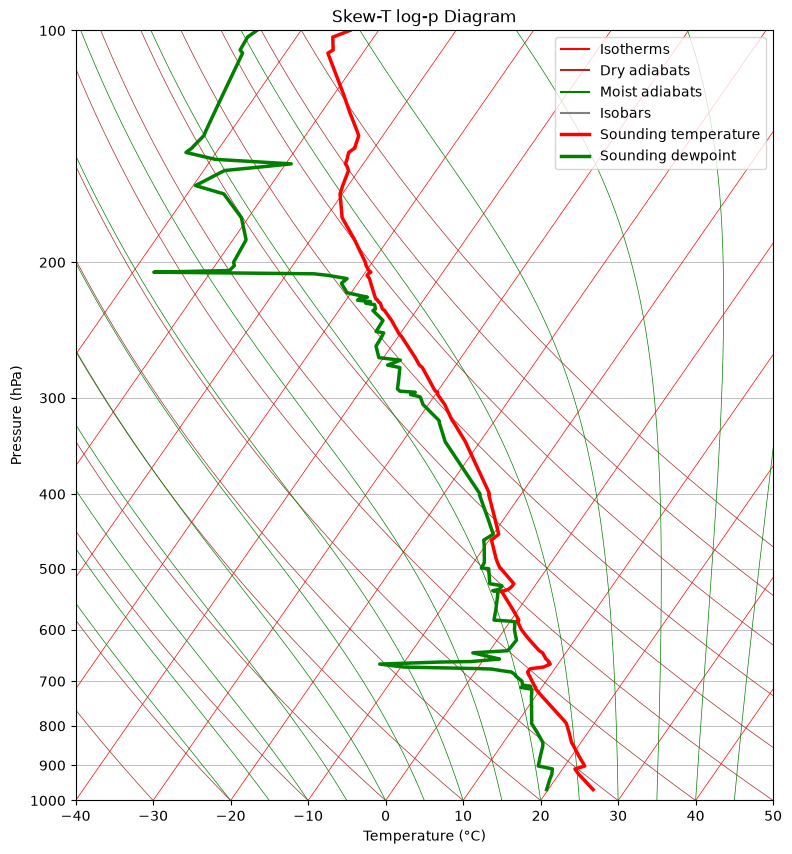

In [27]:
# Plotting Skew-T


fig, ax = plt.subplots(figsize=(9, 10))
skew = -30

# Isotherms plotted with range outside of -40 to 50 degrees Celsius to ensure that the isotherms cover the entire range of the plot
for temp in range(-80, 61, 10):
    ax.plot(skewT(temp, p, skew), p, color="red", linewidth=0.5)


# Dry adiabats: specify parcel potential temperature at 1000 hPa
for start_temp in range(-40, 101, 10):
    curve = dry_adiabat(start_temp, p)
    ax.plot(skewT(curve, p, skew), p, color="brown", linewidth=0.5) 

# Moist adiabats plotted
for start_temp_c in range(-20, 51, 5):
    curve = moist_adiabat(start_temp_c, p)
    ax.plot(skewT(curve, p, skew), p, color="green", linewidth=0.5) 


# Setting the y-axis to a logarithmic scale and defining the limits and ticks for the axes
ax.set_yscale("log")
ax.set_ylim(1000, 100)
ax.set_xlim(-40, 50)
ax.set_xticks(np.arange(-40, 51, 10))
ax.set_yticks([1000, 900, 800, 700, 600, 500, 400, 300, 200, 100])
ax.set_yticklabels(["1000", "900", "800", "700", "600", "500", "400", "300", "200", "100"])
ax.grid(axis="y", which="major", color="gray", linewidth=0.7, alpha=0.5)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Skew-T log-p Diagram")

# Legend for the different variables that were plotted on the skew-T diagram
ax.plot([], [], color="red", label="Isotherms")
ax.plot([], [], color="brown", label="Dry adiabats")
ax.plot([], [], color="green", label="Moist adiabats")
ax.plot([], [], color="gray", label="Isobars")


# Plotting example sounding from OUN station on September 30, 2026 at 12Z (temperature and dewpoint)
ax.plot(skewT(sound_t, sound_p, skew), sound_p,color="red", linewidth=2.5, label="Sounding temperature")
ax.plot(skewT(sound_td, sound_p, skew), sound_p, color="green", linewidth=2.5, label="Sounding dewpoint")

# Setting the legend location to the upper right corner of the plot and displaying the plot
ax.legend(loc="upper right")
plt.show()
ax.legend(loc="upper right")
plt.show()

** Interpretation Prompts **

1. The moist adiabatic lapse rate generally increases as a saturated parcel ascends and cools because the air pacel will condense, causing more latent heat to be released at warmer temperatures at the surface. This latent heat will offset the cooling that occurs due to the expansion of the parcel as it ascends initially. This agrees with the statement that saturated air parcels cool slower than unsaturated air parcels. As the parcel becomes colder with height, saturation vapor pressure decreases strongly. With colder temperatures, less water vapor condenses, causing less latent heat to be released as the air parcel rises. This is occurring at the same time as the saturation vapor pressure is decreasing with cooler temperatures. This causes a stronger adiabatic lapse rate as a saturated air parcel ascends.

2. At the same pressure, warmer saturated air parcels cool slower than colder saturated air parcels because it has a smaller moist adiabatic lapse rate. Saturation vapor pressure also increases strongly with temperature, causing warmer air parcels to have a higher saturation mixing ratio. Condensation in the warmer parcel will produce more latent heat as the air parcel rises, offsetting the cooling that happens as the parcel rises. The cooler air parcel has less water vapor, which causes less latent heat release, which will cause the the air parcel to cool quicker as it rises. This explains why cooler temperatures at the same pressure have the moist adiabat more curved at that pressure, due to less water vapor producing more latent heat. 

3. I originally set my skew value at -20, but then I used a range of skew values in intervals of 10 between 0 and -50. While exploring these options, I saw that the isotherms became vertical parallel to the y-axis at  skew=0 and became more skewed as the skew values decreased to -50. The actual dewpoint and temperature profiles became more vertical as the isotherms became more skewed. This shows how temperatures decrease throughout the atmosphere going from higher to lower pressure. All in all, the skew of the skew-T log-p diagram focuses on the interpretability and the readability of the diagram. That is why I changed my skew value to -30 after this exercise because you are able to see more of the temperature and dewpoint profiles as the skew-T profile became more vertical because of the isotherms becoming more skewed.

4. There is a pretty decent temperature inversion around 675 mb which is where the temperature of the environment actually increases with height. This is not a large temperature inversion, but it is still recognizable to the observer. This means that there is a layer of stability in this layer of the sounding, because as a parcel would rise from 675 mb, following the moist adiabat, it would be cooler than the temperature of the environment. Another interesting feature of this sounding is the dry slot that occurs between 680 and 625 mb. The dewpoints drastically decrease in this part of the sounding, most likely causing no cloud coverage in this layer of the sounding and creating a level of subsidence. This continues to add to the stability of this layer as this is relatively the same pressure level that the temperature inversion is occurring. 

5. The most challenging step for this lab was creating the function for the moist adiabats, as I had to gather a few other equations than the ones provided to integrate into the moist adabatic lapse rate equation. I navigated it by the hint in the lab that was I needed pressure as the vertical coordinates, so I manipuated the hydrostatic equation and the ideal gas law to create pressure coordinates. I leaned on GenAI tools to help structure the for loop for the moist adiabats, more specifically, how to use the natural logs of pressure in the final equation. Figuring out how to structure the final equation was a struggle, but I was able to figure out the final form. I checked what Copilot gave me by doing the integration and calculations myself before and after to confirm the process was done correctly. It also helped with the proofs of the moist adiabats, more specifically, giving me a clearer picture of how I would compare the moist adiabatic lapse rate with the dry adiabatic lapse rate. 